In [1]:
import tensorflow as tf

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(r"D:\ML\Experiment_5 dataset\english.csv")
df

,image,label
0,Img/img001-001.png,0
1,Img/img001-002.png,0
2,Img/img001-003.png,0
3,Img/img001-004.png,0
4,Img/img001-005.png,0
...,...,...
3405,Img/img062-051.png,z
3406,Img/img062-052.png,z
3407,Img/img062-053.png,z
3408,Img/img062-054.png,z


In [4]:
import os
import cv2
import numpy as np

imgpath = r"D:\ML\Experiment_5 dataset"

images = []
labels = []

for index, row in df.iterrows():
    
    img_path = os.path.join(imgpath, row['image'])
    
    # FIX: load as grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        print(f"Image not found: {img_path}")
        continue

    img = cv2.resize(img, (28, 28))
    
    img = img / 255.0
    
    img = img.flatten()
    
    images.append(img)
    labels.append(row['label'])

X = np.array(images)
y = np.array(labels)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (3410, 784)
Shape of y: (3410,)


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical


In [6]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Original labels:", y)
print("Encoded labels:", y_encoded)


Original labels: ['0' '0' '0' ... 'z' 'z' 'z']
Encoded labels: [ 0  0  0 ... 61 61 61]


In [34]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y_encoded,test_size=0.2,random_state=42,stratify=y_encoded
)
print("train shape:",X_train.shape)
print("test shape:",X_test.shape)

train shape: (2728, 784)
test shape: (682, 784)


In [35]:
from tensorflow.keras.utils import to_categorical

y_train_oh = to_categorical(y_train)
y_test_oh = to_categorical(y_test)

print("y_train one hot shape:", y_train_oh.shape)
print("y_test one hot shape:", y_test_oh.shape)

y_train one hot shape: (2728, 62)
y_test one hot shape: (682, 62)


In [36]:
import numpy as np

class BinaryPerceptron:
    
    def __init__(self, learning_rate=0.01, epochs=10):
        
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
    
    
    def step_function(self, x):
        
        return np.where(x >= 0, 1, -1)
    
    
    def train(self, X, y):
        
        n_samples, n_features = X.shape
        
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for epoch in range(self.epochs):
            
            errors = 0
            
            for i in range(n_samples):
                
                linear_output = np.dot(X[i], self.weights) + self.bias
                
                y_pred = self.step_function(linear_output)
                
                update = self.lr * (y[i] - y_pred)
                
                if update != 0:
                    errors += 1
                
                self.weights += update * X[i]
                self.bias += update
            
            print(f"Epoch {epoch+1}, Errors: {errors}")
    
    
    def predict_score(self, X):
        
        return np.dot(X, self.weights) + self.bias

In [37]:
class MultiClassPerceptron:
    
    def __init__(self, learning_rate=0.01, epochs=10):
        
        self.lr = learning_rate
        self.epochs = epochs
        self.perceptrons = {}
        self.classes = None
    
    
    def train(self, X, y):
        
        self.classes = np.unique(y)
        
        for cls in self.classes:
            
            print("Training class:", cls)
            
            y_binary = np.where(y == cls, 1, -1)
            
            perceptron = BinaryPerceptron(self.lr, self.epochs)
            
            perceptron.train(X, y_binary)
            
            self.perceptrons[cls] = perceptron
    
    
    def predict(self, X):
        
        scores = []
        
        for cls in self.classes:
            
            score = self.perceptrons[cls].predict_score(X)
            
            scores.append(score)
        
        scores = np.array(scores)
        
        predictions = np.argmax(scores, axis=0)
        
        return self.classes[predictions]

In [38]:
pla = MultiClassPerceptron(
    learning_rate=0.01,
    epochs=10
)

pla.train(X_train, y_train)

Training class: 0
Epoch 1, Errors: 85
Epoch 2, Errors: 84
Epoch 3, Errors: 84
Epoch 4, Errors: 84
Epoch 5, Errors: 80
Epoch 6, Errors: 86
Epoch 7, Errors: 84
Epoch 8, Errors: 82
Epoch 9, Errors: 80
Epoch 10, Errors: 82
Training class: 1
Epoch 1, Errors: 88
Epoch 2, Errors: 81
Epoch 3, Errors: 82
Epoch 4, Errors: 75
Epoch 5, Errors: 82
Epoch 6, Errors: 75
Epoch 7, Errors: 82
Epoch 8, Errors: 79
Epoch 9, Errors: 74
Epoch 10, Errors: 82
Training class: 2
Epoch 1, Errors: 85
Epoch 2, Errors: 86
Epoch 3, Errors: 78
Epoch 4, Errors: 80
Epoch 5, Errors: 81
Epoch 6, Errors: 78
Epoch 7, Errors: 82
Epoch 8, Errors: 86
Epoch 9, Errors: 72
Epoch 10, Errors: 74
Training class: 3
Epoch 1, Errors: 85
Epoch 2, Errors: 84
Epoch 3, Errors: 84
Epoch 4, Errors: 81
Epoch 5, Errors: 72
Epoch 6, Errors: 70
Epoch 7, Errors: 70
Epoch 8, Errors: 74
Epoch 9, Errors: 78
Epoch 10, Errors: 78
Training class: 4
Epoch 1, Errors: 89
Epoch 2, Errors: 88
Epoch 3, Errors: 85
Epoch 4, Errors: 84
Epoch 5, Errors: 77
Epoch 

In [39]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_pla = pla.predict(X_test)

pla_accuracy = accuracy_score(y_test, y_pred_pla)

print("PLA Accuracy:", pla_accuracy * 100)

print(classification_report(y_test, y_pred_pla, zero_division=0))

PLA Accuracy: 11.29032258064516
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.00      0.00      0.00        11
           2       0.21      0.27      0.24        11
           3       0.00      0.00      0.00        11
           4       0.04      0.45      0.08        11
           5       0.00      0.00      0.00        11
           6       0.00      0.00      0.00        11
           7       0.00      0.00      0.00        11
           8       1.00      0.09      0.17        11
           9       0.07      0.73      0.12        11
          10       0.00      0.00      0.00        11
          11       0.00      0.00      0.00        11
          12       0.50      0.36      0.42        11
          13       0.50      0.09      0.15        11
          14       0.00      0.00      0.00        11
          15       0.22      0.45      0.29        11
          16       0.00      0.00      0.00      

In [40]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

mlp = Sequential()

mlp.add(Input(shape=(784,)))

mlp.add(Dense(256, activation='relu'))

mlp.add(Dense(128, activation='relu'))

mlp.add(Dense(62, activation='softmax'))

optimizer = Adam(learning_rate=0.001)

mlp.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mlp.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 62)                  │           7,998 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 241,854 (944.74 KB)

 Trainable params: 241,854 (944.74 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
history = mlp.fit(
    X_train,
    y_train_oh,
    epochs=50,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2762 - loss: 2.7982 - val_accuracy: 0.2308 - val_loss: 3.0546
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2778 - loss: 2.7854 - val_accuracy: 0.2088 - val_loss: 3.0172
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2925 - loss: 2.7695 - val_accuracy: 0.2711 - val_loss: 2.9586
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2978 - loss: 2.7306 - val_accuracy: 0.2418 - val_loss: 3.0026
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2884 - loss: 2.7407 - val_accuracy: 0.2271 - val_loss: 3.0422
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2965 - loss: 2.6766 - val_accuracy: 0.2674 - val_loss: 2.9099
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2998 - loss: 2.6696 - val_accuracy: 0.2821 - val_loss: 2.9182
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3145 - loss: 2.6699 - val_accuracy: 0.2454 - val_loss:

In [44]:
test_loss, test_accuracy = mlp.evaluate(X_test, y_test_oh)

print("MLP Accuracy:", test_accuracy * 100)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3284 - loss: 2.5873 
MLP Accuracy: 32.84457623958588


In [45]:
learning_rates = [0.01, 0.001, 0.0005]
batch_sizes = [32, 64]
optimizers = ['sgd', 'adam']
activations = ['relu', 'tanh']


In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam


def build_mlp(activation, optimizer_name, learning_rate):
    model = Sequential()
    
    model.add(Dense(256, activation=activation, input_shape=(784,)))
    model.add(Dense(128, activation=activation))
    model.add(Dense(num_classes, activation='softmax'))

    if optimizer_name == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)
    else:
        optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [47]:
results = []

for activation in activations:
    for opt in optimizers:
        for lr in learning_rates:
            for batch in batch_sizes:
                print(f"Training: Act={activation}, Opt={opt}, LR={lr}, Batch={batch}")

                model = build_mlp(activation, opt, lr)

                model.fit(
                    X_train,
                    y_train_cat,
                    epochs=30,
                    batch_size=batch,
                    validation_split=0.1,
                    verbose=0
                )

                loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
                results.append([activation, opt, lr, batch, acc])


Training: Act=relu, Opt=sgd, LR=0.01, Batch=32


C:\Users\jayas\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training: Act=relu, Opt=sgd, LR=0.01, Batch=64
Training: Act=relu, Opt=sgd, LR=0.001, Batch=32
Training: Act=relu, Opt=sgd, LR=0.001, Batch=64
Training: Act=relu, Opt=sgd, LR=0.0005, Batch=32
Training: Act=relu, Opt=sgd, LR=0.0005, Batch=64
Training: Act=relu, Opt=adam, LR=0.01, Batch=32
Training: Act=relu, Opt=adam, LR=0.01, Batch=64
Training: Act=relu, Opt=adam, LR=0.001, Batch=32
Training: Act=relu, Opt=adam, LR=0.001, Batch=64
Training: Act=relu, Opt=adam, LR=0.0005, Batch=32
Training: Act=relu, Opt=adam, LR=0.0005, Batch=64
Training: Act=tanh, Opt=sgd, LR=0.01, Batch=32
Training: Act=tanh, Opt=sgd, LR=0.01, Batch=64
Training: Act=tanh, Opt=sgd, LR=0.001, Batch=32
Training: Act=tanh, Opt=sgd, LR=0.001, Batch=64
Training: Act=tanh, Opt=sgd, LR=0.0005, Batch=32
Training: Act=tanh, Opt=sgd, LR=0.0005, Batch=64
Training: Act=tanh, Opt=adam, LR=0.01, Batch=32
Training: Act=tanh, Opt=adam, LR=0.01, Batch=64
Training: Act=tanh, Opt=adam, LR=0.001, Batch=32
Training: Act=tanh, Opt=adam, LR

In [49]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=['Activation', 'Optimizer', 'Learning Rate', 'Batch Size', 'Accuracy']
)

print(results_df.sort_values(by='Accuracy', ascending=False))


   Activation Optimizer  Learning Rate  Batch Size  Accuracy
22       tanh      adam         0.0005          32  0.343109
23       tanh      adam         0.0005          64  0.337243
21       tanh      adam         0.0010          64  0.309384
11       relu      adam         0.0005          64  0.287390
10       relu      adam         0.0005          32  0.255132
0        relu       sgd         0.0100          32  0.241935
9        relu      adam         0.0010          64  0.239003
12       tanh       sgd         0.0100          32  0.230205
8        relu      adam         0.0010          32  0.209677
20       tanh      adam         0.0010          32  0.197947
1        relu       sgd         0.0100          64  0.123167
13       tanh       sgd         0.0100          64  0.115836
2        relu       sgd         0.0010          32  0.038123
14       tanh       sgd         0.0010          32  0.036657
4        relu       sgd         0.0005          32  0.027859
5        relu       sgd 

In [50]:
best_params = results_df.loc[results_df['Accuracy'].idxmax()]
print("Best Hyperparameters:")
print(best_params)


Best Hyperparameters:
Activation           tanh
Optimizer            adam
Learning Rate      0.0005
Batch Size             32
Accuracy         0.343109
Name: 22, dtype: object


In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns


In [52]:
pla_accuracy = accuracy_score(y_test, y_pred_pla)
pla_precision = precision_score(y_test, y_pred_pla, average='macro', zero_division=0)
pla_recall = recall_score(y_test, y_pred_pla, average='macro', zero_division=0)
pla_f1 = f1_score(y_test, y_pred_pla, average='macro', zero_division=0)

print("PLA Performance:")
print("Accuracy :", pla_accuracy)
print("Precision:", pla_precision)
print("Recall   :", pla_recall)
print("F1-score :", pla_f1)


PLA Performance:
Accuracy : 0.11290322580645161
Precision: 0.19516695764177436
Recall   : 0.1129032258064516
F1-score : 0.08416065534997896


In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert probabilities → class labels
y_pred_mlp = np.argmax(mlp.predict(X_test), axis=1)

# Calculate metrics
mlp_accuracy = accuracy_score(y_test, y_pred_mlp)

mlp_precision = precision_score(
    y_test,
    y_pred_mlp,
    average='macro',
    zero_division=0
)

mlp_recall = recall_score(
    y_test,
    y_pred_mlp,
    average='macro',
    zero_division=0
)

mlp_f1 = f1_score(
    y_test,
    y_pred_mlp,
    average='macro',
    zero_division=0
)

# Print results
print("\nMLP Performance:")
print("Accuracy :", mlp_accuracy)
print("Precision:", mlp_precision)
print("Recall   :", mlp_recall)
print("F1-score :", mlp_f1)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

MLP Performance:
Accuracy : 0.3284457478005865
Precision: 0.33855332354992035
Recall   : 0.3284457478005864
F1-score : 0.3142043386305969


In [55]:
comparison_df = pd.DataFrame({
    "Model": ["PLA (OvR)", "MLP (Tuned)"],
    "Accuracy": [pla_accuracy, mlp_accuracy],
    "Precision": [pla_precision, mlp_precision],
    "Recall": [pla_recall, mlp_recall],
    "F1-score": [pla_f1, mlp_f1]
})

print(comparison_df)


         Model  Accuracy  Precision    Recall  F1-score
0    PLA (OvR)  0.112903   0.195167  0.112903  0.084161
1  MLP (Tuned)  0.328446   0.338553  0.328446  0.314204


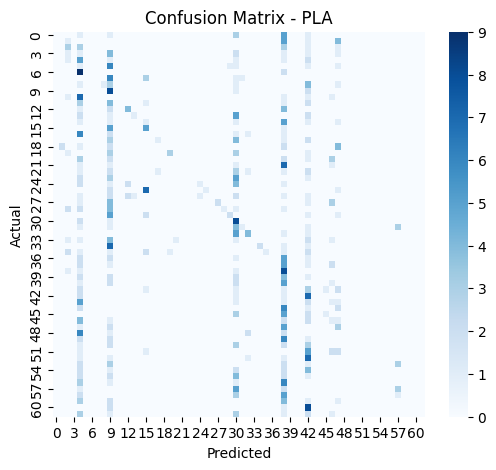

In [56]:
cm_pla = confusion_matrix(y_test, y_pred_pla)

plt.figure(figsize=(6,5))
sns.heatmap(cm_pla, cmap="Blues", cbar=True)
plt.title("Confusion Matrix - PLA")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


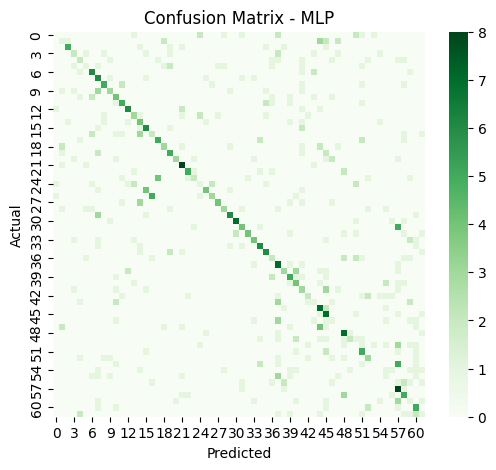

In [57]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6,5))
sns.heatmap(cm_mlp, cmap="Greens", cbar=True)
plt.title("Confusion Matrix - MLP")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


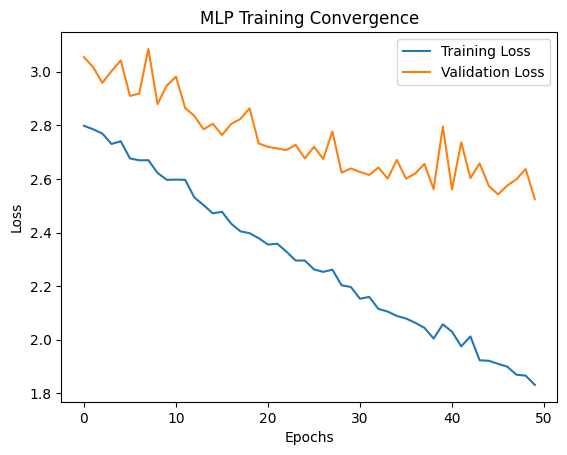

In [58]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MLP Training Convergence")
plt.legend()
plt.show()


In [59]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np


In [61]:
# Get probability scores from MLP
y_score = mlp.predict(X_test)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [62]:
y_test_bin = label_binarize(y_test, classes=range(num_classes))


In [63]:
fpr_micro, tpr_micro, _ = roc_curve(
    y_test_bin.ravel(),
    y_score.ravel()
)

roc_auc_micro = auc(fpr_micro, tpr_micro)


In [64]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes

fpr_macro = all_fpr
tpr_macro = mean_tpr
roc_auc_macro = auc(fpr_macro, tpr_macro)


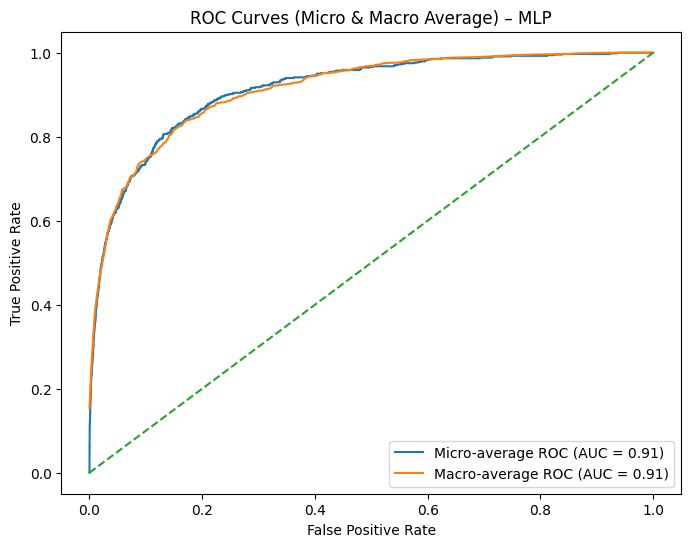

In [65]:
plt.figure(figsize=(8,6))

plt.plot(fpr_micro, tpr_micro,
         label=f'Micro-average ROC (AUC = {roc_auc_micro:.2f})')

plt.plot(fpr_macro, tpr_macro,
         label=f'Macro-average ROC (AUC = {roc_auc_macro:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (Micro & Macro Average) – MLP')
plt.legend()
plt.show()
